# M4.Ex2: Penguins Classification (PyCaret)

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M6/exercises/ex2_pycaret_classification.ipynb)

## Exercise

Your task is to follow the steps outlined here, and apply them on the **Palmer Penguins Dataset** below:

- [**🚀 Classification**](https://pycaret.gitbook.io/docs/get-started/quickstart#classification)
    - Setup
    - Compare Models
    - Analyze Model
    - Predictions
    - Save the model

## Palmer Penguins Dataset

The goal of palmer penguins is to provide a great dataset for data exploration & visualization, as an alternative to iris.

The data contains 344 penguins. There are 3 different species of penguins in this dataset, collected from 3 islands in the Palmer Archipelago, Antarctica.

- Features: `4` numerical, `2` categorical
- Target: `species` (Categorical / 3 classes)
- Size: `344` samples
- Source: [Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/)

### Load the data

In [1]:
import seaborn as sns

penguins = sns.load_dataset('penguins')
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Experiments

1. **First experiment**:
    - X = Flipper Length (numerical) & Bill Length (numerical)
    - y = Species (categorical)
2. **Second experiment**:
    - X = Weights (numerical) & Species (categorical)
    - y = Sex (categroical)
3. **Third experiment**:
    - X = `island`, `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`
    - y = Sex and Species (multi-label classification)

In [2]:
from pycaret.classification import *

data1 = penguins[['flipper_length_mm', 'bill_length_mm', 'species']]
s1 = ClassificationExperiment()
s1.setup(data1, target='species', session_id=123)

best_model1 = s1.compare_models()


,Description,Value
0,Session id,123
1,Target,species
2,Target type,Multiclass
3,Target mapping,"Adelie: 0, Chinstrap: 1, Gentoo: 2"
4,Original data shape,"(344, 3)"
5,Transformed data shape,"(344, 3)"
6,Transformed train set shape,"(240, 3)"
7,Transformed test set shape,"(104, 3)"
8,Numeric features,2
9,Rows with missing values,0.6%


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9542,0.9867,0.9542,0.9608,0.9550,0.9287,0.9309,0.0240
knn,K Neighbors Classifier,0.9500,0.9767,0.9500,0.9544,0.9482,0.9207,0.9237,0.1340
gbc,Gradient Boosting Classifier,0.9458,0.0000,0.9458,0.9550,0.9465,0.9159,0.9194,0.0280
lr,Logistic Regression,0.9417,0.0000,0.9417,0.9475,0.9406,0.9080,0.9113,0.1640
dt,Decision Tree Classifier,0.9417,0.9574,0.9417,0.9482,0.9424,0.9090,0.9115,0.0060
ridge,Ridge Classifier,0.9417,0.0000,0.9417,0.9472,0.9397,0.9071,0.9106,0.0060
lda,Linear Discriminant Analysis,0.9417,0.0000,0.9417,0.9472,0.9397,0.9071,0.9106,0.0050
nb,Naive Bayes,0.9375,0.9879,0.9375,0.9419,0.9366,0.9016,0.9044,0.0050
qda,Quadratic Discriminant Analysis,0.9375,0.0000,0.9375,0.9419,0.9354,0.9010,0.9047,0.0060
et,Extra Trees Classifier,0.9375,0.9914,0.9375,0.9473,0.9382,0.9031,0.9070,0.0180


In [3]:
from pycaret.classification import *
penguins= penguins.dropna(subset=['sex'])
data2 = penguins[['body_mass_g', 'species', 'sex']]
s2 = ClassificationExperiment()
s2.setup(data2, target='sex', session_id=123)

best_model2 = s2.compare_models()

,Description,Value
0,Session id,123
1,Target,sex
2,Target type,Binary
3,Target mapping,"Female: 0, Male: 1"
4,Original data shape,"(333, 3)"
5,Transformed data shape,"(333, 5)"
6,Transformed train set shape,"(233, 5)"
7,Transformed test set shape,"(100, 5)"
8,Numeric features,1
9,Categorical features,1


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.8627,0.9139,0.8627,0.8683,0.8617,0.7249,0.7305,0.0150
ridge,Ridge Classifier,0.8591,0.9459,0.8591,0.8623,0.8586,0.7176,0.7209,0.0090
lda,Linear Discriminant Analysis,0.8551,0.9423,0.8551,0.8594,0.8544,0.7097,0.7141,0.0080
lr,Logistic Regression,0.8543,0.9344,0.8543,0.8587,0.8539,0.7083,0.7127,0.0090
et,Extra Trees Classifier,0.8373,0.8657,0.8373,0.8489,0.8354,0.6737,0.6852,0.0200
dt,Decision Tree Classifier,0.8371,0.8546,0.8371,0.8467,0.8352,0.6737,0.6832,0.0080
lightgbm,Light Gradient Boosting Machine,0.8330,0.9314,0.8330,0.8433,0.8306,0.6647,0.6752,18.5190
rf,Random Forest Classifier,0.8288,0.9043,0.8288,0.8357,0.8273,0.6569,0.6639,0.0240
gbc,Gradient Boosting Classifier,0.8201,0.9197,0.8201,0.8269,0.8184,0.6392,0.6461,0.0170
knn,K Neighbors Classifier,0.7944,0.8399,0.7944,0.8035,0.7926,0.5879,0.5970,0.1360


In [4]:

penguins['combined_target'] = penguins['sex'].astype(str) + "_" + penguins['species'].astype(str)

exp3_data = penguins[['island', 'bill_length_mm', 'bill_depth_mm', 
                            'flipper_length_mm', 'body_mass_g', 'combined_target']]


s3 = ClassificationExperiment()
s3.setup(data=exp3_data, target='combined_target', session_id=123)


best_model3 = s3.compare_models()

,Description,Value
0,Session id,123
1,Target,combined_target
2,Target type,Multiclass
3,Target mapping,"Female_Adelie: 0, Female_Chinstrap: 1, Female_Gentoo: 2, Male_Adelie: 3, Male_Chinstrap: 4, Male_Gentoo: 5"
4,Original data shape,"(333, 6)"
5,Transformed data shape,"(333, 8)"
6,Transformed train set shape,"(233, 8)"
7,Transformed test set shape,"(100, 8)"
8,Numeric features,4
9,Categorical features,1


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.8971,0.9909,0.8971,0.9145,0.8945,0.8739,0.8778,0.0270
et,Extra Trees Classifier,0.8967,0.9936,0.8967,0.9092,0.8917,0.8736,0.8779,0.0210
lightgbm,Light Gradient Boosting Machine,0.8933,0.9850,0.8933,0.9090,0.8895,0.8695,0.8738,121.3590
gbc,Gradient Boosting Classifier,0.8928,0.0000,0.8928,0.9158,0.8904,0.8689,0.8742,0.0570
lda,Linear Discriminant Analysis,0.8924,0.0000,0.8924,0.9138,0.8899,0.8683,0.8736,0.0070
ridge,Ridge Classifier,0.8409,0.0000,0.8409,0.8580,0.8331,0.8047,0.8108,0.0080
dt,Decision Tree Classifier,0.8281,0.8972,0.8281,0.8478,0.8221,0.7903,0.7963,0.0080
lr,Logistic Regression,0.8201,0.0000,0.8201,0.8301,0.8123,0.7799,0.7860,0.0200
nb,Naive Bayes,0.7808,0.9770,0.7808,0.8833,0.7889,0.7381,0.7594,0.0080
knn,K Neighbors Classifier,0.6661,0.8747,0.6661,0.6801,0.6448,0.5889,0.6012,0.0120


### Analyze Model

In [7]:
s1.evaluate_model(best_model1)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

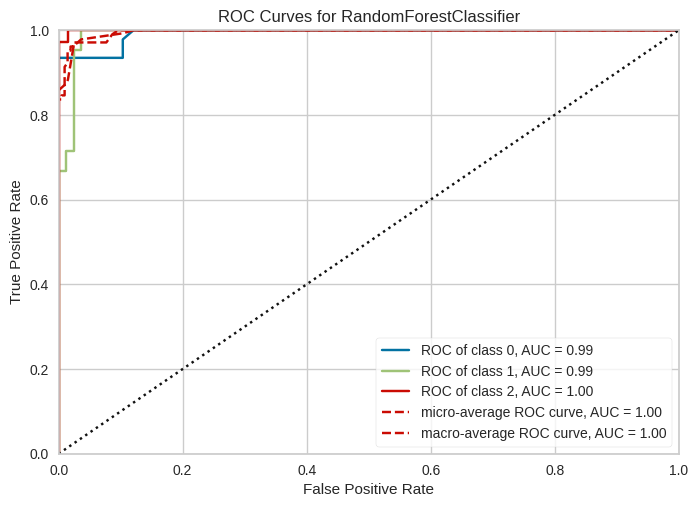

In [10]:
s1.plot_model(best_model1, plot = 'auc')

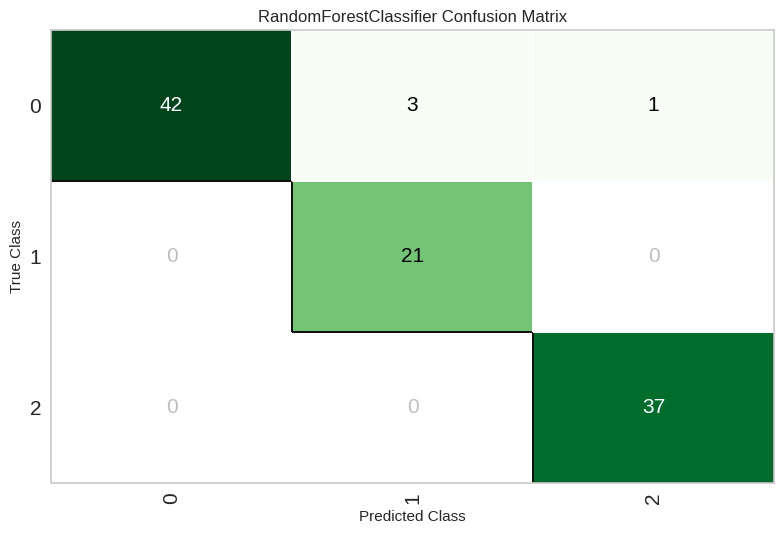

In [13]:
s1.plot_model(best_model1, plot = 'confusion_matrix')

In [8]:
s2.evaluate_model(best_model2)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

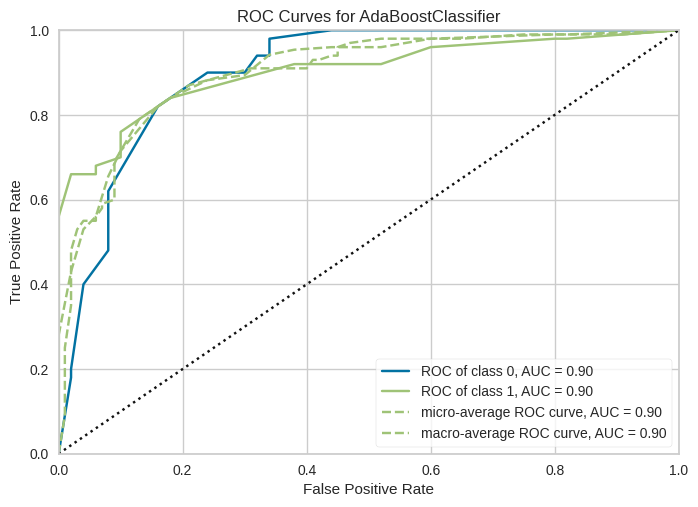

In [11]:
s2.plot_model(best_model2, plot = 'auc')

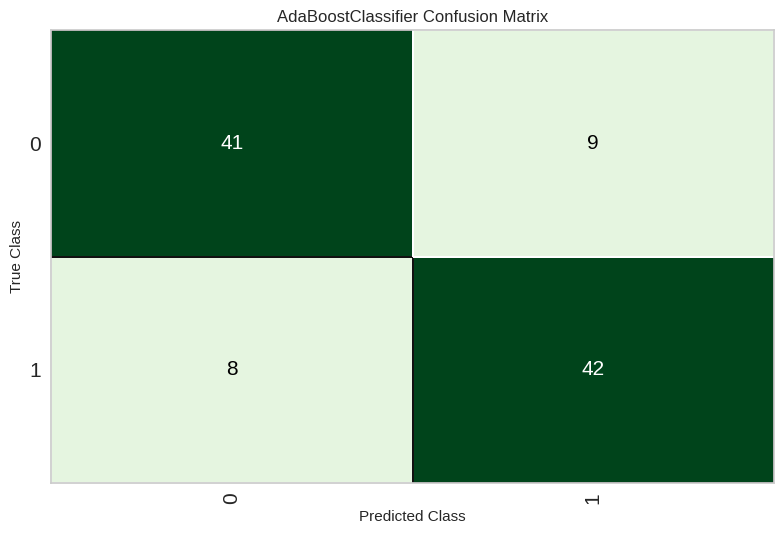

In [14]:
s2.plot_model(best_model2, plot = 'confusion_matrix')

In [9]:
s3.evaluate_model(best_model3)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

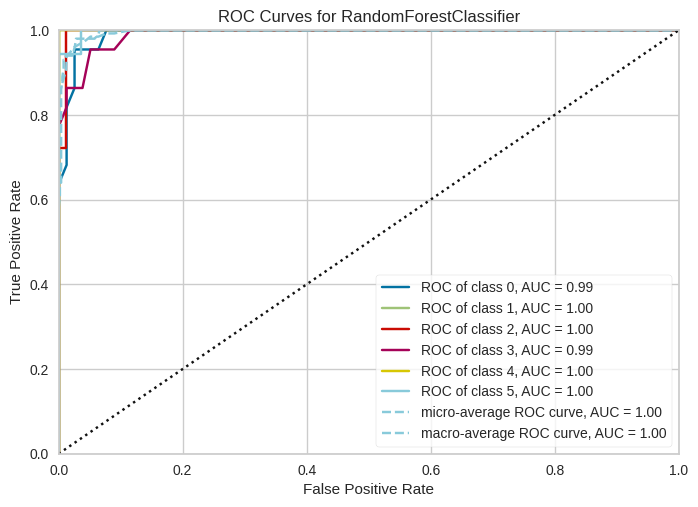

In [12]:
s3.plot_model(best_model3, plot = 'auc')

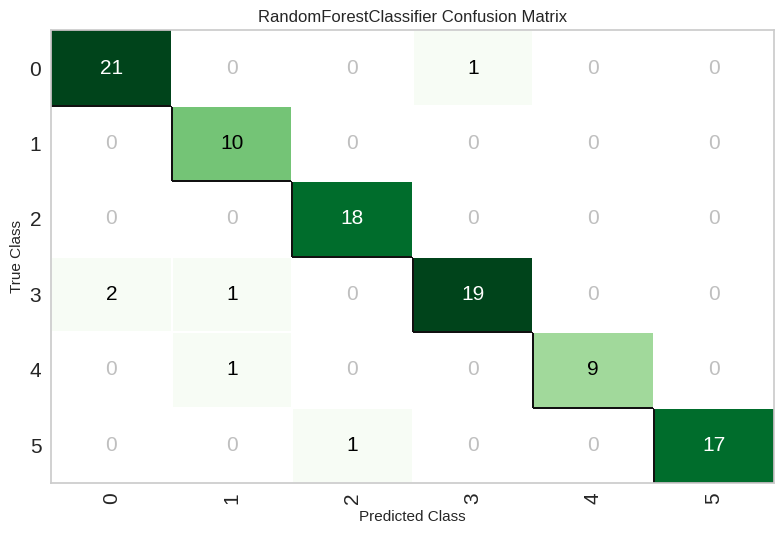

In [15]:
s3.plot_model(best_model3, plot = 'confusion_matrix')

### Predictions

In [ ]:
s1.predict_model(best_model1)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9615,0.9952,0.9615,0.9654,0.9617,0.9403,0.9422


,flipper_length_mm,bill_length_mm,species,prediction_label,prediction_score
166,190.0,45.900002,Chinstrap,Chinstrap,0.79
96,190.0,38.099998,Adelie,Adelie,1.00
157,198.0,45.200001,Chinstrap,Chinstrap,0.68
259,208.0,48.700001,Gentoo,Gentoo,0.90
210,202.0,50.200001,Chinstrap,Chinstrap,0.95
...,...,...,...,...,...
278,208.0,43.200001,Gentoo,Gentoo,0.92
32,188.0,39.500000,Adelie,Adelie,0.99
185,203.0,51.000000,Chinstrap,Chinstrap,0.93
149,193.0,37.799999,Adelie,Adelie,1.00


In [21]:
predictions = s1.predict_model(best_model1, data=penguins)
predictions.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9910,0.9993,0.9910,0.9914,0.9910,0.9859,0.9861


,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,combined_target,species,prediction_label,prediction_score
0,Torgersen,39.099998,18.700001,181.0,3750.0,Male,Male_Adelie,Adelie,Adelie,1.0
1,Torgersen,39.500000,17.400000,186.0,3800.0,Female,Female_Adelie,Adelie,Adelie,1.0
2,Torgersen,40.299999,18.000000,195.0,3250.0,Female,Female_Adelie,Adelie,Adelie,1.0
4,Torgersen,36.700001,19.299999,193.0,3450.0,Female,Female_Adelie,Adelie,Adelie,1.0
5,Torgersen,39.299999,20.600000,190.0,3650.0,Male,Male_Adelie,Adelie,Adelie,1.0


In [24]:
# OOP API
predictions = s1.predict_model(best_model1, data=penguins, raw_score=True)
predictions.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9910,0.9993,0.9910,0.9914,0.9910,0.9859,0.9861


,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,combined_target,species,prediction_label,prediction_score_Adelie,prediction_score_Chinstrap,prediction_score_Gentoo
0,Torgersen,39.099998,18.700001,181.0,3750.0,Male,Male_Adelie,Adelie,Adelie,1.0,0.0,0.0
1,Torgersen,39.500000,17.400000,186.0,3800.0,Female,Female_Adelie,Adelie,Adelie,1.0,0.0,0.0
2,Torgersen,40.299999,18.000000,195.0,3250.0,Female,Female_Adelie,Adelie,Adelie,1.0,0.0,0.0
4,Torgersen,36.700001,19.299999,193.0,3450.0,Female,Female_Adelie,Adelie,Adelie,1.0,0.0,0.0
5,Torgersen,39.299999,20.600000,190.0,3650.0,Male,Male_Adelie,Adelie,Adelie,1.0,0.0,0.0


In [17]:
s2.predict_model(best_model2)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.8300,0.9020,0.8300,0.8301,0.8300,0.6600,0.6601


,body_mass_g,species,sex,prediction_label,prediction_score
211,3525.0,Chinstrap,Female,Female,0.5048
219,3775.0,Chinstrap,Female,Male,0.5070
116,2900.0,Adelie,Female,Female,0.6786
242,4400.0,Gentoo,Female,Female,0.5268
99,4100.0,Adelie,Male,Male,0.5199
...,...,...,...,...,...
38,3300.0,Adelie,Female,Female,0.5063
202,3325.0,Chinstrap,Female,Female,0.5190
4,3450.0,Adelie,Female,Female,0.5102
250,5250.0,Gentoo,Male,Male,0.6768


In [22]:
predictions = s2.predict_model(best_model2, data=penguins)
predictions.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.8679,0.9431,0.8679,0.8679,0.8679,0.7357,0.7357


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,combined_target,sex,prediction_label,prediction_score
0,Adelie,Torgersen,39.099998,18.700001,181.0,3750.0,Male_Adelie,Male,Male,0.5070
1,Adelie,Torgersen,39.500000,17.400000,186.0,3800.0,Female_Adelie,Female,Male,0.5028
2,Adelie,Torgersen,40.299999,18.000000,195.0,3250.0,Female_Adelie,Female,Female,0.6786
4,Adelie,Torgersen,36.700001,19.299999,193.0,3450.0,Female_Adelie,Female,Female,0.5102
5,Adelie,Torgersen,39.299999,20.600000,190.0,3650.0,Male_Adelie,Male,Female,0.5048


In [25]:
# OOP API
predictions = s2.predict_model(best_model2, data=penguins, raw_score=True)
predictions.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.8679,0.9431,0.8679,0.8679,0.8679,0.7357,0.7357


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,combined_target,sex,prediction_label,prediction_score_Female,prediction_score_Male
0,Adelie,Torgersen,39.099998,18.700001,181.0,3750.0,Male_Adelie,Male,Male,0.4930,0.5070
1,Adelie,Torgersen,39.500000,17.400000,186.0,3800.0,Female_Adelie,Female,Male,0.4972,0.5028
2,Adelie,Torgersen,40.299999,18.000000,195.0,3250.0,Female_Adelie,Female,Female,0.6786,0.3214
4,Adelie,Torgersen,36.700001,19.299999,193.0,3450.0,Female_Adelie,Female,Female,0.5102,0.4898
5,Adelie,Torgersen,39.299999,20.600000,190.0,3650.0,Male_Adelie,Male,Female,0.5048,0.4952


In [18]:
s3.predict_model(best_model3)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9400,0.9951,0.9400,0.9437,0.9400,0.9268,0.9275


,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,combined_target,prediction_label,prediction_score
97,Dream,40.299999,18.500000,196.0,4350.0,Male_Adelie,Male_Adelie,0.85
266,Biscoe,45.500000,13.900000,210.0,4200.0,Female_Gentoo,Female_Gentoo,0.98
137,Dream,40.200001,20.100000,200.0,3975.0,Male_Adelie,Male_Adelie,0.86
195,Dream,45.500000,17.000000,196.0,3500.0,Female_Chinstrap,Female_Chinstrap,0.78
6,Torgersen,38.900002,17.799999,181.0,3625.0,Female_Adelie,Female_Adelie,0.76
...,...,...,...,...,...,...,...,...
304,Biscoe,44.900002,13.800000,212.0,4750.0,Female_Gentoo,Female_Gentoo,1.00
174,Dream,43.200001,16.600000,187.0,2900.0,Female_Chinstrap,Female_Chinstrap,0.79
171,Dream,49.200001,18.200001,195.0,4400.0,Male_Chinstrap,Male_Chinstrap,0.60
44,Dream,37.000000,16.900000,185.0,3000.0,Female_Adelie,Female_Adelie,0.96


In [23]:
predictions = s3.predict_model(best_model3, data=penguins)
predictions.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9820,0.9994,0.9820,0.9824,0.9820,0.9780,0.9781


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,combined_target,prediction_label,prediction_score
0,Adelie,Torgersen,39.099998,18.700001,181.0,3750.0,Male,Male_Adelie,Male_Adelie,0.77
1,Adelie,Torgersen,39.500000,17.400000,186.0,3800.0,Female,Female_Adelie,Female_Adelie,0.90
2,Adelie,Torgersen,40.299999,18.000000,195.0,3250.0,Female,Female_Adelie,Female_Adelie,0.94
4,Adelie,Torgersen,36.700001,19.299999,193.0,3450.0,Female,Female_Adelie,Female_Adelie,0.69
5,Adelie,Torgersen,39.299999,20.600000,190.0,3650.0,Male,Male_Adelie,Male_Adelie,0.84


In [26]:
# OOP API
predictions = s3.predict_model(best_model3, data=penguins, raw_score=True)
predictions.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9820,0.9994,0.9820,0.9824,0.9820,0.9780,0.9781


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,combined_target,prediction_label,prediction_score_Female_Adelie,prediction_score_Female_Chinstrap,prediction_score_Female_Gentoo,prediction_score_Male_Adelie,prediction_score_Male_Chinstrap,prediction_score_Male_Gentoo
0,Adelie,Torgersen,39.099998,18.700001,181.0,3750.0,Male,Male_Adelie,Male_Adelie,0.20,0.02,0.0,0.77,0.01,0.0
1,Adelie,Torgersen,39.500000,17.400000,186.0,3800.0,Female,Female_Adelie,Female_Adelie,0.90,0.00,0.0,0.10,0.00,0.0
2,Adelie,Torgersen,40.299999,18.000000,195.0,3250.0,Female,Female_Adelie,Female_Adelie,0.94,0.00,0.0,0.06,0.00,0.0
4,Adelie,Torgersen,36.700001,19.299999,193.0,3450.0,Female,Female_Adelie,Female_Adelie,0.69,0.00,0.0,0.30,0.01,0.0
5,Adelie,Torgersen,39.299999,20.600000,190.0,3650.0,Male,Male_Adelie,Male_Adelie,0.16,0.00,0.0,0.84,0.00,0.0


### save the model

In [28]:
s1.save_model(best_model1, 'my_best_pipeline1')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['flipper_length_mm',
                                              'bill_length_mm'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               miss...
                  RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                         class_weight=None, criterion='gini',

In [29]:
s2.save_model(best_model1, 'my_best_pipeline2')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None, include=['body_mass_g'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               missing_values=nan,
                                                               strategy...
                  RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                         class_weight=None, criterion='gini',
                   

In [30]:
s3.save_model(best_model1, 'my_best_pipeline3')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['bill_length_mm', 'bill_depth_mm',
                                              'flipper_length_mm',
                                              'body_mass_g'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,...
                  RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                         class_weight=None, criterion='gini',
                                         max_depth=None, max_features='sqrt',
 

# Lode models 

In [32]:
# functional API
from pathlib import Path
from pycaret.regression import load_model
base_path = Path("/home/mona/Downloads/SAD/AAI/student/ML/Module 6")

model1 = load_model(str(base_path / "my_best_pipeline1"))
model2 = load_model(str(base_path / "my_best_pipeline2"))
model3 = load_model(str(base_path / "my_best_pipeline3"))

Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
